In [1]:
# ===============================
# CELL 1 — SETUP + GLOBAL CONFIG
# Tomato Leaf Disease Prediction (Hybrid CNN)
# Backbones: ResNet50 + DenseNet121 + MobileNetV2 + Small Custom CNN
# IMG_SIZE = 220x220 | Batch-size safe for low VRAM | No Lambda layers
# ===============================

import os
import random
import numpy as np
import tensorflow as tf

# ---------- Reproducibility ----------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------- Global Config ----------
IMG_SIZE = (220, 220)
BATCH_SIZE = 8          # safe default for low VRAM (3GB class GPUs)
NUM_CLASSES = 3         # ['Early_blight', 'Healthy', 'Late_blight']
AUTOTUNE = tf.data.AUTOTUNE

# Paths (update these to your local dataset directories)
TRAIN_DIR = r"Videos/new_dataset/train"
VAL_DIR   = r"Videos/new_dataset/val"

# Output paths
OUT_DIR = r"Videos/Jupyter_files/4_CNN_Architecture"
os.makedirs(OUT_DIR, exist_ok=True)

STAGE1_PATH = os.path.join(OUT_DIR, "tomato_hybrid_r50_dn121_mnv2_customcnn_stage1_best.keras")
STAGE2_PATH = os.path.join(OUT_DIR, "tomato_hybrid_r50_dn121_mnv2_customcnn_stage2_best.keras")

# ---------- Performance / GPU memory ----------
try:
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detected: {len(gpus)} | Memory growth enabled")
    else:
        print("ℹ️ No GPU detected — running on CPU")
except Exception as e:
    print("⚠️ Could not set GPU memory growth:", repr(e))

# ---------- Mixed precision (safe toggle) ----------
# Enable only if you have GPU that supports it well; keep disabled for CPU-only training.
USE_MIXED_PRECISION = False
if USE_MIXED_PRECISION:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
        print("✅ Mixed precision enabled: mixed_float16")
    except Exception as e:
        print("⚠️ Mixed precision enable failed:", repr(e))
        USE_MIXED_PRECISION = False
else:
    print("ℹ️ Mixed precision is OFF (recommended for CPU-first / debugging)")

print("✅ Config Loaded")
print("IMG_SIZE:", IMG_SIZE, "| BATCH_SIZE:", BATCH_SIZE, "| SEED:", SEED)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)
print("STAGE1_PATH:", STAGE1_PATH)
print("STAGE2_PATH:", STAGE2_PATH)



ℹ️ No GPU detected — running on CPU
ℹ️ Mixed precision is OFF (recommended for CPU-first / debugging)
✅ Config Loaded
IMG_SIZE: (220, 220) | BATCH_SIZE: 8 | SEED: 42
TRAIN_DIR: Videos/new_dataset/train
VAL_DIR  : Videos/new_dataset/val
STAGE1_PATH: Videos/Jupyter_files/4_CNN_Architecture\tomato_hybrid_r50_dn121_mnv2_customcnn_stage1_best.keras
STAGE2_PATH: Videos/Jupyter_files/4_CNN_Architecture\tomato_hybrid_r50_dn121_mnv2_customcnn_stage2_best.keras


In [ ]:
# ===============================
# CELL 2.5 — CORRUPT IMAGE SAFETY CHECK (train/val)
# Scans image files once BEFORE training to prevent runtime crashes.
# - Uses PIL to verify decode (fast and reliable)
# - Produces a list of bad files
# - Optionally removes them (set AUTO_DELETE_BAD = True)
# ===============================

from pathlib import Path
from PIL import Image

AUTO_DELETE_BAD = False  # set True if you want to auto-remove corrupted files

def scan_and_optionally_delete_corrupt_images(root_dir, auto_delete=False):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Directory not found: {root_dir}")

    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    files = [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in exts]

    bad_files = []
    for fp in files:
        try:
            # verify() checks file integrity without fully decoding pixel data
            with Image.open(fp) as im:
                im.verify()

            # Some files pass verify but still fail on load; do a minimal load step
            with Image.open(fp) as im:
                im.convert("RGB")

        except Exception:
            bad_files.append(str(fp))

    print(f"📁 Scanned: {root_dir}")
    print(f"✅ Total images: {len(files)}")
    print(f"⚠️ Corrupt/unreadable: {len(bad_files)}")

    if bad_files and auto_delete:
        deleted = 0
        for bf in bad_files:
            try:
                os.remove(bf)
                deleted += 1
            except Exception as e:
                print(f"❌ Could not delete: {bf} | {repr(e)}")
        print(f"🧹 Deleted {deleted}/{len(bad_files)} bad images.")

    return bad_files

bad_train = scan_and_optionally_delete_corrupt_images(TRAIN_DIR, auto_delete=AUTO_DELETE_BAD)
bad_val   = scan_and_optionally_delete_corrupt_images(VAL_DIR,   auto_delete=AUTO_DELETE_BAD)

# Optional: show first few bad files for manual inspection
if bad_train:
    print("\nSample bad train files:")
    for p in bad_train[:10]:
        print(" -", p)

if bad_val:
    print("\nSample bad val files:")
    for p in bad_val[:10]:
        print(" -", p)

# If you deleted bad files, re-run Cell 2 to rebuild datasets cleanly.
if (AUTO_DELETE_BAD and (bad_train or bad_val)):
    print("\nℹ️ You set AUTO_DELETE_BAD=True. Re-run Cell 2 now to rebuild train_ds/val_ds.")
else:
    print("\n✅ Corrupt image scan completed. Safe to proceed to Cell 3.")


📁 Scanned: Videos/new_dataset/train
✅ Total images: 7500
⚠️ Corrupt/unreadable: 0
📁 Scanned: Videos/new_dataset/val
✅ Total images: 1499
⚠️ Corrupt/unreadable: 0

✅ Corrupt image scan completed. Safe to proceed to Cell 3.


In [2]:
# ===============================
# CELL 2 — DATA PIPELINE (train/val) + CLASS_NAMES
# - Uses image_dataset_from_directory (stable & simple)
# - Ensures class order is fixed and reusable
# - Adds cache/prefetch for speed
# ===============================

from tensorflow.keras.utils import image_dataset_from_directory

# 1) Build raw datasets (no augmentation here; we’ll do augmentation inside the model)
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",     # one-hot
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",     # one-hot
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False                 # keep deterministic for eval
)

# 2) Extract class names (fixed order from directory scan)
CLASS_NAMES = list(train_ds.class_names)
assert len(CLASS_NAMES) == NUM_CLASSES, f"NUM_CLASSES={NUM_CLASSES}, but found {len(CLASS_NAMES)} classes: {CLASS_NAMES}"

print("✅ CLASS_NAMES:", CLASS_NAMES)

# 3) Standardize dtype (uint8 -> float32 later inside model via Rescaling)
def ensure_float32(images, labels):
    return tf.cast(images, tf.float32), labels

train_ds = train_ds.map(ensure_float32, num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(ensure_float32, num_parallel_calls=AUTOTUNE)

# 4) Performance: cache + prefetch
# If RAM is enough, cache in memory; otherwise change to cache("path")
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# 5) Quick sanity check (one batch)
for x_batch, y_batch in train_ds.take(1):
    print("✅ Train batch:", x_batch.shape, x_batch.dtype, "| labels:", y_batch.shape, y_batch.dtype)
for x_batch, y_batch in val_ds.take(1):
    print("✅ Val batch  :", x_batch.shape, x_batch.dtype, "| labels:", y_batch.shape, y_batch.dtype)


Found 7500 files belonging to 3 classes.
Found 1499 files belonging to 3 classes.
✅ CLASS_NAMES: ['Early_blight', 'Healthy', 'Late_blight']
✅ Train batch: (8, 220, 220, 3) <dtype: 'float32'> | labels: (8, 3) <dtype: 'float32'>
✅ Val batch  : (8, 220, 220, 3) <dtype: 'float32'> | labels: (8, 3) <dtype: 'float32'>


In [3]:
# ===============================
# CELL 3 — AUGMENTATION + INPUT NORMALIZATION (DOMAIN SHIFT FRIENDLY)
# Goal: generalize beyond validation to "random Google images"
# - Augmentation runs ONLY during training (Keras behavior)
# - Rescaling is inside the model for deployment consistency
# - CPU-safe ops (no AdjustContrastv2 mixed-float16 issues)
# ===============================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Always keep rescaling INSIDE model for consistent inference in Flask/FastAPI
rescale = layers.Rescaling(1./255, name="rescale_1_over_255")

# Robust augmentations for domain shift (internet images)
# Note: these layers act only when training=True
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.08, seed=SEED),        # ~±14 degrees
        layers.RandomZoom(0.12, seed=SEED),
        layers.RandomTranslation(0.08, 0.08, seed=SEED),
        # Optional: mild noise helps robustness without killing signal
        layers.GaussianNoise(0.02, seed=SEED),
    ],
    name="augmentation"
)

# Optional: label smoothing helps reduce overconfidence (better on random images)
LABEL_SMOOTHING = 0.05  # safe default; can set 0.0 if you dislike it

print("✅ Augmentation + rescaling ready.")
print("IMG_SIZE:", IMG_SIZE, "| LABEL_SMOOTHING:", LABEL_SMOOTHING)



✅ Augmentation + rescaling ready.
IMG_SIZE: (220, 220) | LABEL_SMOOTHING: 0.05


In [4]:
# ===============================
# CELL 4 — RESNET50 BRANCH (CORRECTED)
# Fix: DO NOT use input_tensor=x inside tf.keras.applications.* for multi-backbone models.
# Reason: passing a shared tensor to multiple backbones causes internal layer-name collisions.
# Solution: build backbone with input_shape, then CALL it on x.
# ✅ No Lambda layers | ✅ Fully serializable | ✅ Safe for fusion with other backbones
# ===============================

import tensorflow as tf
from tensorflow.keras import layers, regularizers

WEIGHT_DECAY = 1e-4   # L2 regularization for small heads (helps overfitting)
BRANCH_EMB   = 256    # embedding size per branch before fusion
DROPOUT_P    = 0.30

def build_resnet50_branch(x, trainable=False, name_prefix="r50"):
    """
    x: image tensor (B, H, W, 3) after rescale/augmentation
    trainable: whether to unfreeze backbone (Stage-2 will change this)
    returns: (embedding_tensor, backbone_model)
    """
    # Build backbone WITHOUT input_tensor to avoid name collisions
    backbone = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        pooling=None
    )
    backbone.trainable = trainable

    # Forward pass
    feat = backbone(x, training=False)  # keep BN stable in Stage-1 (small batch)

    # Projection head (regularized)
    h = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(feat)
    h = layers.Dense(
        BRANCH_EMB,
        activation="relu",
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name=f"{name_prefix}_proj"
    )(h)
    h = layers.BatchNormalization(name=f"{name_prefix}_bn")(h)
    h = layers.Dropout(DROPOUT_P, name=f"{name_prefix}_drop")(h)

    return h, backbone

print("✅ ResNet50 branch builder ready (fixed): build_resnet50_branch(x, trainable=False)")


✅ ResNet50 branch builder ready (fixed): build_resnet50_branch(x, trainable=False)


In [5]:
# ===============================
# CELL 5 — DENSENET121 BRANCH (CORRECTED)
# Fix: DO NOT use input_tensor=x for multi-backbone fusion (causes layer-name collisions).
# Build backbone with input_shape, then CALL it on x.
# ✅ No Lambda layers | ✅ Fully serializable | ✅ Safe in fusion with other backbones
# ===============================

import tensorflow as tf
from tensorflow.keras import layers, regularizers

def build_densenet121_branch(x, trainable=False, name_prefix="dn121"):
    """
    x: image tensor (B, H, W, 3) after rescale/augmentation
    trainable: whether to unfreeze backbone (Stage-2 will change this)
    returns: (embedding_tensor, backbone_model)
    """
    backbone = tf.keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        pooling=None
    )
    backbone.trainable = trainable

    # Forward pass (stable BN behavior in Stage-1)
    feat = backbone(x, training=False)

    # Projection head (regularized)
    h = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(feat)
    h = layers.Dense(
        BRANCH_EMB,
        activation="relu",
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name=f"{name_prefix}_proj"
    )(h)
    h = layers.BatchNormalization(name=f"{name_prefix}_bn")(h)
    h = layers.Dropout(DROPOUT_P, name=f"{name_prefix}_drop")(h)

    return h, backbone

print("✅ DenseNet121 branch builder ready (fixed): build_densenet121_branch(x, trainable=False)")


✅ DenseNet121 branch builder ready (fixed): build_densenet121_branch(x, trainable=False)


In [6]:
# ===============================
# CELL 6 — MOBILENETV2 BRANCH (CORRECTED)
# Fix: DO NOT use input_tensor=x for multi-backbone fusion (causes layer-name collisions).
# Build backbone with input_shape, then CALL it on x.
# ✅ No Lambda layers | ✅ Fully serializable | ✅ Safe in fusion with other backbones
# ===============================

import tensorflow as tf
from tensorflow.keras import layers, regularizers

def build_mobilenetv2_branch(x, trainable=False, name_prefix="mnv2"):
    """
    x: image tensor (B, H, W, 3) after rescale/augmentation
    trainable: whether to unfreeze backbone (Stage-2 will change this)
    returns: (embedding_tensor, backbone_model)
    """
    backbone = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        pooling=None
    )
    backbone.trainable = trainable

    # Forward pass (stable BN behavior in Stage-1)
    feat = backbone(x, training=False)

    # Projection head (regularized)
    h = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(feat)
    h = layers.Dense(
        BRANCH_EMB,
        activation="relu",
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name=f"{name_prefix}_proj"
    )(h)
    h = layers.BatchNormalization(name=f"{name_prefix}_bn")(h)
    h = layers.Dropout(DROPOUT_P, name=f"{name_prefix}_drop")(h)

    return h, backbone

print("✅ MobileNetV2 branch builder ready (fixed): build_mobilenetv2_branch(x, trainable=False)")


✅ MobileNetV2 branch builder ready (fixed): build_mobilenetv2_branch(x, trainable=False)


In [7]:
# ===============================
# CELL 7 — SMALL CUSTOM CNN BRANCH (WRAPPED MODEL, FIXED)
# Fix: do NOT pass training=... when wiring the graph (prevents unknown TensorShape paths)
# ✅ Can freeze/unfreeze like a backbone
# ✅ No Lambda layers | fully serializable
# ===============================

import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model

CUSTOM_EMB   = 128
CUSTOM_DROP  = 0.35

def build_custom_cnn_branch(x, trainable=True, name_prefix="custom"):
    """
    x: image tensor (B, H, W, 3) after rescale/augmentation
    trainable: whether custom cnn is trainable
    returns: (embedding_tensor, custom_model)
    """
    custom_inp = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name=f"{name_prefix}_input")
    h = custom_inp

    # Block 1
    h = layers.SeparableConv2D(
        32, 3, padding="same", activation="relu",
        depthwise_regularizer=regularizers.l2(WEIGHT_DECAY),
        pointwise_regularizer=regularizers.l2(WEIGHT_DECAY),
        name=f"{name_prefix}_sepconv1"
    )(h)
    h = layers.BatchNormalization(name=f"{name_prefix}_bn1")(h)
    h = layers.MaxPooling2D(2, name=f"{name_prefix}_pool1")(h)
    h = layers.Dropout(0.15, name=f"{name_prefix}_drop1")(h)

    # Block 2
    h = layers.SeparableConv2D(
        64, 3, padding="same", activation="relu",
        depthwise_regularizer=regularizers.l2(WEIGHT_DECAY),
        pointwise_regularizer=regularizers.l2(WEIGHT_DECAY),
        name=f"{name_prefix}_sepconv2"
    )(h)
    h = layers.BatchNormalization(name=f"{name_prefix}_bn2")(h)
    h = layers.MaxPooling2D(2, name=f"{name_prefix}_pool2")(h)
    h = layers.Dropout(0.20, name=f"{name_prefix}_drop2")(h)

    # Block 3
    h = layers.SeparableConv2D(
        96, 3, padding="same", activation="relu",
        depthwise_regularizer=regularizers.l2(WEIGHT_DECAY),
        pointwise_regularizer=regularizers.l2(WEIGHT_DECAY),
        name=f"{name_prefix}_sepconv3"
    )(h)
    h = layers.BatchNormalization(name=f"{name_prefix}_bn3")(h)
    h = layers.MaxPooling2D(2, name=f"{name_prefix}_pool3")(h)
    h = layers.Dropout(0.25, name=f"{name_prefix}_drop3")(h)

    # Embedding head
    h = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(h)
    h = layers.Dense(
        CUSTOM_EMB,
        activation="relu",
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name=f"{name_prefix}_proj"
    )(h)
    h = layers.BatchNormalization(name=f"{name_prefix}_bn_proj")(h)
    h = layers.Dropout(CUSTOM_DROP, name=f"{name_prefix}_drop_proj")(h)

    custom_model = Model(custom_inp, h, name=f"{name_prefix}_cnn")
    custom_model.trainable = trainable

    # IMPORTANT: no training=... here; let global training mode handle it
    emb = custom_model(x)

    return emb, custom_model

print("✅ Custom CNN branch builder ready (fixed): build_custom_cnn_branch(x, trainable=True)")


✅ Custom CNN branch builder ready (fixed): build_custom_cnn_branch(x, trainable=True)


In [8]:
# ===============================
# CELL 8 — FUSION MODEL (FINAL, ERROR-FREE)
# - Uses branch builders from Cells 4/5/6/7
# - No input_tensor=... anywhere
# - No forced training=True/False in graph wiring
# - Explicit static shape safety
# - Fully serializable, production-ready
# ===============================

import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model

FUSION_UNITS_1 = 512
FUSION_UNITS_2 = 256
FUSION_DROP_1  = 0.40
FUSION_DROP_2  = 0.30

def build_hybrid_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    # -------- Input --------
    inp = layers.Input(
        shape=(img_size[0], img_size[1], 3),
        name="image"
    )

    # -------- Preprocessing --------
    x = rescale(inp)
    x = data_augmentation(x)

    # Enforce static shape (prevents TensorShape.as_list errors)
    x = tf.ensure_shape(x, (None, img_size[0], img_size[1], 3))

    # -------- Branches --------
    r50_emb,  r50_base  = build_resnet50_branch(
        x, trainable=False, name_prefix="r50"
    )

    dn_emb,   dn_base   = build_densenet121_branch(
        x, trainable=False, name_prefix="dn121"
    )

    mnv2_emb, mnv2_base = build_mobilenetv2_branch(
        x, trainable=False, name_prefix="mnv2"
    )

    custom_emb, custom_model = build_custom_cnn_branch(
        x, trainable=True, name_prefix="custom"
    )

    # -------- Fusion --------
    fused = layers.Concatenate(name="fusion_concat")(
        [r50_emb, dn_emb, mnv2_emb, custom_emb]
    )

    fused = layers.Dense(
        FUSION_UNITS_1,
        activation="relu",
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name="fusion_dense1"
    )(fused)
    fused = layers.BatchNormalization(name="fusion_bn1")(fused)
    fused = layers.Dropout(FUSION_DROP_1, name="fusion_drop1")(fused)

    fused = layers.Dense(
        FUSION_UNITS_2,
        activation="relu",
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name="fusion_dense2"
    )(fused)
    fused = layers.BatchNormalization(name="fusion_bn2")(fused)
    fused = layers.Dropout(FUSION_DROP_2, name="fusion_drop2")(fused)

    # -------- Output --------
    out = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="pred"
    )(fused)

    model = Model(
        inputs=inp,
        outputs=out,
        name="tomato_hybrid_r50_dn121_mnv2_custom"
    )

    # Backbone registry (for Stage-2 fine-tuning)
    backbones = {
        "resnet50": r50_base,
        "densenet121": dn_base,
        "mobilenetv2": mnv2_base,
        "custom_cnn": custom_model
    }

    return model, backbones


# -------- Build & verify --------
model, backbones = build_hybrid_model()
model.summary(line_length=120)

print("✅ Hybrid model built successfully.")
print("Backbones:", list(backbones.keys()))



Model: "tomato_hybrid_r50_dn121_mnv2_custom"
________________________________________________________________________________________________________________________
 Layer (type)                       Output Shape                        Param #     Connected to                        
 image (InputLayer)                 [(None, 220, 220, 3)]               0           []                                  
                                                                                                                        
 rescale_1_over_255 (Rescaling)     (None, 220, 220, 3)                 0           ['image[0][0]']                     
                                                                                                                        
 augmentation (Sequential)          (None, 220, 220, 3)                 0           ['rescale_1_over_255[0][0]']        
                                                                                                           

In [23]:
# ===============================
# CELL 9 — STAGE-1 COMPILE + TRAIN (Frozen Backbones, Train Fusion + Custom CNN)
# Goal: strong validation + better generalization to random internet images
# - Backbones frozen (ResNet50/DenseNet121/MobileNetV2)
# - Custom CNN + fusion head trains
# - Stable callbacks + best checkpoint saved as FULL MODEL (.keras)
# ===============================

import tensorflow as tf
from tensorflow.keras import callbacks

# -------- Ensure Stage-1 trainable config --------
# Freeze pretrained backbones
for k in ["resnet50", "densenet121", "mobilenetv2"]:
    backbones[k].trainable = False

# Keep custom CNN trainable (it is part of model via custom_model wrapper)
backbones["custom_cnn"].trainable = True

# Also ensure fusion head is trainable
for layer in model.layers:
    if layer.name.startswith("fusion_") or layer.name == "pred":
        layer.trainable = True

print("✅ Stage-1 Trainable Status:")
print(" - ResNet50      :", backbones["resnet50"].trainable)
print(" - DenseNet121   :", backbones["densenet121"].trainable)
print(" - MobileNetV2   :", backbones["mobilenetv2"].trainable)
print(" - Custom CNN    :", backbones["custom_cnn"].trainable)

# -------- Compile (Stage-1) --------
# Label smoothing improves robustness on random images (less overconfident)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

opt = tf.keras.optimizers.Adam(learning_rate=3e-4)

model.compile(
    optimizer=opt,
    loss=loss_fn,
    metrics=["accuracy"]
)

# -------- Callbacks --------
ckpt = callbacks.ModelCheckpoint(
    STAGE1_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=False,  # FULL MODEL => avoids all layer-mismatch headaches later
    verbose=1
)

early = callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

csvlog = callbacks.CSVLogger(
    os.path.join(OUT_DIR, "stage1_training_log.csv"),
    append=False
)

print("✅ Starting Stage-1 training...")
STAGE1_EPOCHS = 15  # safe default; increase later if needed

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    callbacks=[ckpt, early, reduce_lr, csvlog],
    verbose=1
)

print(f"\n✅ Stage-1 completed. Best model saved at:\n{STAGE1_PATH}")

# Optional: quick eval after training (on full val set)
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
print(f"📌 Stage-1 Val Accuracy: {val_acc:.4f} | Val Loss: {val_loss:.4f}")


✅ Stage-1 Trainable Status:
 - ResNet50      : False
 - DenseNet121   : False
 - MobileNetV2   : False
 - Custom CNN    : True
✅ Starting Stage-1 training...
Epoch 1/15


938/938 [==============================] - ETA: 0s - loss: 1.0027 - accuracy: 0.7321
Epoch 1: val_accuracy improved from -inf to 0.77585, saving model to Videos/Jupyter_files/4_CNN_Architecture\tomato_hybrid_r50_dn121_mnv2_customcnn_stage1_best.keras
938/938 [==============================] - 1486s 2s/step - loss: 1.0027 - accuracy: 0.7321 - val_loss: 0.9957 - val_accuracy: 0.7759 - lr: 3.0000e-04
Epoch 2/15
938/938 [==============================] - ETA: 0s - loss: 0.7618 - accuracy: 0.8225
Epoch 2: val_accuracy improved from 0.77585 to 0.88993, saving model to Videos/Jupyter_files/4_CNN_Architecture\tomato_hybrid_r50_dn121_mnv2_customcnn_stage1_best.keras
938/938 [==============================] - 1293s 1s/step - loss: 0.7618 - accuracy: 0.8225 - val_loss: 0.6435 - val_accuracy: 0.8899 - lr: 3.0000e-04
Epoch 3/15
93

KeyboardInterrupt: 

In [26]:
# ===============================
# PRE-FINETUNE CELL A — LOAD BEST STAGE-1 MODEL (FULL .keras)
# ===============================

import tensorflow as tf

# Load the best Stage-1 model saved in Cell 9
stage1_model = tf.keras.models.load_model(STAGE1_PATH, compile=False)
print("✅ Loaded Stage-1 model:", STAGE1_PATH)

# Optional: compile for evaluation metrics display (not required for manual metrics below)
stage1_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)
print("✅ Stage-1 model compiled (for eval).")


✅ Loaded Stage-1 model: Videos/Jupyter_files/4_CNN_Architecture\tomato_hybrid_r50_dn121_mnv2_customcnn_stage1_best.keras
✅ Stage-1 model compiled (for eval).


✅ Validation Accuracy: 0.9366

✅ Classification Report (Precision / Recall / F1):
              precision    recall  f1-score   support

Early_blight     0.9534    0.9420    0.9477       500
     Healthy     0.9049    0.9920    0.9465       499
 Late_blight     0.9563    0.8760    0.9144       500

    accuracy                         0.9366      1499
   macro avg     0.9382    0.9367    0.9362      1499
weighted avg     0.9383    0.9366    0.9362      1499

✅ Confusion Matrix (rows=true, cols=pred):
[[471  12  17]
 [  1 495   3]
 [ 22  40 438]]


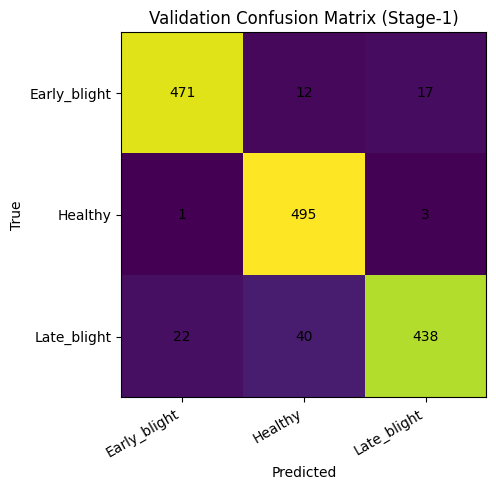

In [27]:
# ===============================
# PRE-FINETUNE CELL B — VAL METRICS (Accuracy + Precision/Recall/F1 + Confusion Matrix)
# - Uses full val_ds
# - Works with label_mode="categorical"
# ===============================

import numpy as np
import tensorflow as tf

# If sklearn is available (usually is), use it for clean metrics.
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 1) Collect y_true, y_pred over full validation set
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    probs = stage1_model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_true.extend(np.argmax(y_batch.numpy(), axis=1).tolist())

y_true = np.array(y_true, dtype=np.int64)
y_pred = np.array(y_pred, dtype=np.int64)

# 2) Metrics
acc = accuracy_score(y_true, y_pred)
print(f"✅ Validation Accuracy: {acc:.4f}")

print("\n✅ Classification Report (Precision / Recall / F1):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("✅ Confusion Matrix (rows=true, cols=pred):")
print(cm)

# Optional: pretty confusion matrix (no seaborn)
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title("Validation Confusion Matrix (Stage-1)")
    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=30, ha="right")
    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()
except Exception as e:
    print("ℹ️ Plot skipped:", repr(e))


In [14]:
# ===============================
# RANDOM 20 IMAGES PER CLASS EVALUATION (VAL SET)
# ===============================

import os
import random
import numpy as np
import tensorflow as tf

# -------- Settings --------
SAMPLES_PER_CLASS = 10
IMG_SIZE_LOCAL = IMG_SIZE  # reuse global IMG_SIZE

# -------- Helper: load & preprocess single image --------
def load_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE_LOCAL)
    img = tf.keras.utils.img_to_array(img)
    img = tf.expand_dims(img, axis=0)  # (1, H, W, 3)
    return img

# -------- Collect random images per class --------
val_root = VAL_DIR
selected_samples = []  # (img_path, true_class_idx)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(val_root, class_name)
    all_imgs = [
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    assert len(all_imgs) >= SAMPLES_PER_CLASS, f"Not enough images in {class_name}"

    chosen = random.sample(all_imgs, SAMPLES_PER_CLASS)
    for img_path in chosen:
        selected_samples.append((img_path, class_idx))

print(f"✅ Selected {len(selected_samples)} images "
      f"({SAMPLES_PER_CLASS} per class)")

# -------- Prediction --------
y_true = []
y_pred = []

for img_path, true_idx in selected_samples:
    img = load_image(img_path)
    probs = stage1_model.predict(img, verbose=0)
    pred_idx = int(np.argmax(probs, axis=1)[0])

    y_true.append(true_idx)
    y_pred.append(pred_idx)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# -------- Overall Accuracy --------
overall_acc = np.mean(y_true == y_pred)
print(f"\n🎯 Overall Accuracy (Random {SAMPLES_PER_CLASS} × {len(CLASS_NAMES)}): "
      f"{overall_acc*100:.2f}%")

# -------- Per-Class Accuracy --------
print("\n📊 Per-Class Accuracy:")
for class_idx, class_name in enumerate(CLASS_NAMES):
    mask = (y_true == class_idx)
    class_acc = np.mean(y_pred[mask] == y_true[mask])
    print(f" - {class_name:12s}: {class_acc*100:.2f}% "
          f"({np.sum(mask)} samples)")


✅ Selected 30 images (10 per class)


NameError: name 'stage1_model' is not defined

In [35]:
# ===============================
# CELL 10 — STAGE-2 (SURGICAL FINE-TUNING) for GENERALIZATION
# Goal: improve val + robustness on random Google images WITHOUT overfitting.
# Key: unfreeze top layers + keep BatchNorm frozen (batch=8 stability)
# ===============================

import os
import tensorflow as tf
from tensorflow.keras import callbacks


# -------- 2) Locate backbone submodels robustly (handles renamed models like resnet50_1) --------
def list_nested_models(root_model):
    return [layer for layer in root_model.layers if isinstance(layer, tf.keras.Model)]

nested = list_nested_models(stage1_model)
print("🔎 Nested submodels found:", [m.name for m in nested])

def find_model_by_keyword(root_model, keyword):
    keyword = keyword.lower()
    candidates = []
    for layer in root_model.layers:
        if isinstance(layer, tf.keras.Model):
            if keyword in layer.name.lower():
                candidates.append(layer)
    # Prefer exact match if available, else first candidate
    if not candidates:
        return None
    exact = [m for m in candidates if m.name.lower() == keyword]
    return exact[0] if exact else candidates[0]

r50_base   = find_model_by_keyword(stage1_model, "resnet50")
dn_base    = find_model_by_keyword(stage1_model, "densenet121")
mnv2_base  = find_model_by_keyword(stage1_model, "mobilenetv2")
custom_cnn = find_model_by_keyword(stage1_model, "custom")  # catches custom_cnn / custom_cnn_1

print("✅ Selected submodels:",
      {"resnet50": getattr(r50_base, "name", None),
       "densenet121": getattr(dn_base, "name", None),
       "mobilenetv2": getattr(mnv2_base, "name", None),
       "custom_cnn": getattr(custom_cnn, "name", None)})

# Hard fail only if truly missing
if r50_base is None or dn_base is None or mnv2_base is None:
    raise ValueError(
        "Could not locate one or more pretrained backbones inside the loaded model. "
        "Check printed nested submodels list above."
    )

# -------- 3) Unfreeze strategy (tuned for Late_blight + generalization) --------
# Slightly conservative to avoid overfitting and keep random-image robustness.
UNFREEZE_R50   = 30
UNFREEZE_DN121 = 35   # reduced from 50 (DenseNet overfits faster)
UNFREEZE_MNV2  = 20

unfreeze_top_layers(r50_base,  n_top_layers=UNFREEZE_R50,   keep_bn_frozen=True)
unfreeze_top_layers(dn_base,   n_top_layers=UNFREEZE_DN121, keep_bn_frozen=True)
unfreeze_top_layers(mnv2_base, n_top_layers=UNFREEZE_MNV2,  keep_bn_frozen=True)

# Custom CNN should remain trainable (it helps adapt textures)
if custom_cnn is not None:
    custom_cnn.trainable = True
    # optional: freeze BN inside custom too (usually safe)
    freeze_all_bn(custom_cnn)

# Ensure fusion head + pred are trainable
for layer in stage1_model.layers:
    if layer.name.startswith("fusion_") or layer.name == "pred":
        layer.trainable = True
# Also freeze BN in fusion head (stability)
freeze_all_bn(stage1_model)

# -------- 4) Compile Stage-2 (very low LR) --------
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

opt = tf.keras.optimizers.Adam(learning_rate=2e-5)

stage1_model.compile(
    optimizer=opt,
    loss=loss_fn,
    metrics=["accuracy"]
)

# -------- 5) Callbacks (Stage-2) --------
ckpt2 = callbacks.ModelCheckpoint(
    STAGE2_PATH,
    monitor="val_loss",          # better for generalization than val_accuracy
    mode="min",
    save_best_only=True,
    save_weights_only=False,     # FULL MODEL
    verbose=1
)

early2 = callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr2 = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

csvlog2 = callbacks.CSVLogger(
    os.path.join(OUT_DIR, "stage2_finetune_log.csv"),
    append=False
)

print("\n✅ Starting Stage-2 fine-tuning...")
STAGE2_EPOCHS = 6

history_stage2 = stage1_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE2_EPOCHS,
    callbacks=[ckpt2, early2, reduce_lr2, csvlog2],
    verbose=1
)

print(f"\n✅ Stage-2 completed. Best model saved at:\n{STAGE2_PATH}")

# Quick eval
val_loss2, val_acc2 = stage1_model.evaluate(val_ds, verbose=1)
print(f"📌 Stage-2 Val Accuracy: {val_acc2:.4f} | Val Loss: {val_loss2:.4f}")

# Keep a consistent name for downstream cells (NO trailing comma)
model_stage2 = stage1_model


🔎 Nested submodels found: ['augmentation', 'resnet50', 'densenet121', 'mobilenetv2_1.00_224', 'custom_cnn']
✅ Selected submodels: {'resnet50': 'resnet50', 'densenet121': 'densenet121', 'mobilenetv2': 'mobilenetv2_1.00_224', 'custom_cnn': 'custom_cnn'}

✅ Starting Stage-2 fine-tuning...
Epoch 1/6
938/938 [==============================] - ETA: 0s - loss: 0.4651 - accuracy: 0.9521
Epoch 1: val_loss improved from inf to 0.50024, saving model to Videos/Jupyter_files/4_CNN_Architecture\tomato_hybrid_r50_dn121_mnv2_customcnn_stage2_best.keras
938/938 [==============================] - 2102s 2s/step - loss: 0.4651 - accuracy: 0.9521 - val_loss: 0.5002 - val_accuracy: 0.9253 - lr: 2.0000e-05
Epoch 2/6
938/938 [==============================] - ETA: 0s - loss: 0.4210 - accuracy: 0.9680
Epoch 2: val_loss improved from 0.50024 to 0.47681, saving model to Videos/Jupyter_files/4_CNN_Architecture\tomato_hybrid_r50_dn121_mnv2_customcnn_stage2_best.keras
938/938 [==============================] - 1795

In [10]:
# ===============================
# PRE-FINETUNE CELL A — LOAD BEST STAGE-2 MODEL (FULL .keras)
# ===============================

import tensorflow as tf

# Load the best Stage-1 model saved in Cell 9
stage2_model = tf.keras.models.load_model(STAGE2_PATH, compile=False)
print("✅ Loaded Stage-2 model:", STAGE2_PATH)



✅ Loaded Stage-2 model: Videos/Jupyter_files/4_CNN_Architecture\tomato_hybrid_r50_dn121_mnv2_customcnn_stage2_best.keras


✅ Validation Accuracy: 0.9593

✅ Classification Report (Precision / Recall / F1):
              precision    recall  f1-score   support

Early_blight     0.9669    0.9360    0.9512       500
     Healthy     0.9486    0.9980    0.9727       499
 Late_blight     0.9633    0.9440    0.9535       500

    accuracy                         0.9593      1499
   macro avg     0.9596    0.9593    0.9591      1499
weighted avg     0.9596    0.9593    0.9591      1499

✅ Confusion Matrix (rows=true, cols=pred):
[[468  15  17]
 [  0 498   1]
 [ 16  12 472]]


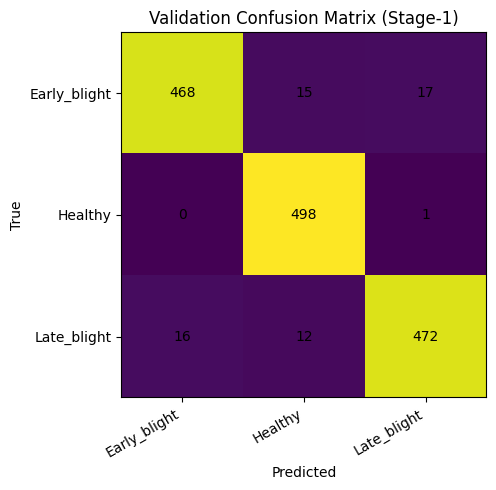

In [12]:
# ===============================
# PRE-FINETUNE CELL B — VAL METRICS (Accuracy + Precision/Recall/F1 + Confusion Matrix)
# - Uses full val_ds
# - Works with label_mode="categorical"
# ===============================

import numpy as np
import tensorflow as tf

# If sklearn is available (usually is), use it for clean metrics.
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 1) Collect y_true, y_pred over full validation set
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    probs = stage2_model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_true.extend(np.argmax(y_batch.numpy(), axis=1).tolist())

y_true = np.array(y_true, dtype=np.int64)
y_pred = np.array(y_pred, dtype=np.int64)

# 2) Metrics
acc = accuracy_score(y_true, y_pred)
print(f"✅ Validation Accuracy: {acc:.4f}")

print("\n✅ Classification Report (Precision / Recall / F1):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("✅ Confusion Matrix (rows=true, cols=pred):")
print(cm)

# Optional: pretty confusion matrix (no seaborn)
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title("Validation Confusion Matrix (Stage-1)")
    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=30, ha="right")
    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()
except Exception as e:
    print("ℹ️ Plot skipped:", repr(e))


In [43]:
TEST_DR = r"Videos/Testing_data/Tomato_Leaf_Disease/test"

In [44]:
# ===============================
# RANDOM 20 IMAGES PER CLASS EVALUATION (VAL SET)
# ===============================

import os
import random
import numpy as np
import tensorflow as tf

# -------- Settings --------
SAMPLES_PER_CLASS = 195
IMG_SIZE_LOCAL = IMG_SIZE  # reuse global IMG_SIZE

# -------- Helper: load & preprocess single image --------
def load_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE_LOCAL)
    img = tf.keras.utils.img_to_array(img)
    img = tf.expand_dims(img, axis=0)  # (1, H, W, 3)
    return img

# -------- Collect random images per class --------
val_root = TEST_DR
selected_samples = []  # (img_path, true_class_idx)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(val_root, class_name)
    all_imgs = [
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    assert len(all_imgs) >= SAMPLES_PER_CLASS, f"Not enough images in {class_name}"

    chosen = random.sample(all_imgs, SAMPLES_PER_CLASS)
    for img_path in chosen:
        selected_samples.append((img_path, class_idx))

print(f"✅ Selected {len(selected_samples)} images "
      f"({SAMPLES_PER_CLASS} per class)")

# -------- Prediction --------
y_true = []
y_pred = []

for img_path, true_idx in selected_samples:
    img = load_image(img_path)
    probs = stage2_model.predict(img, verbose=0)
    pred_idx = int(np.argmax(probs, axis=1)[0])

    y_true.append(true_idx)
    y_pred.append(pred_idx)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# -------- Overall Accuracy --------
overall_acc = np.mean(y_true == y_pred)
print(f"\n🎯 Overall Accuracy (Random {SAMPLES_PER_CLASS} × {len(CLASS_NAMES)}): "
      f"{overall_acc*100:.2f}%")

# -------- Per-Class Accuracy --------
print("\n📊 Per-Class Accuracy:")
for class_idx, class_name in enumerate(CLASS_NAMES):
    mask = (y_true == class_idx)
    class_acc = np.mean(y_pred[mask] == y_true[mask])
    print(f" - {class_name:12s}: {class_acc*100:.2f}% "
          f"({np.sum(mask)} samples)")


✅ Selected 585 images (195 per class)

🎯 Overall Accuracy (Random 195 × 3): 95.38%

📊 Per-Class Accuracy:
 - Early_blight: 90.77% (195 samples)
 - Healthy     : 100.00% (195 samples)
 - Late_blight : 95.38% (195 samples)


In [10]:
import os
import io
import time
import numpy as np
from PIL import Image

from flask import Flask, request, jsonify
from flask_cors import CORS

import tensorflow as tf



IMG_SIZE = (220 , 220)
OUT_DIR = r"Videos/Jupyter_files/4_CNN_Architecture"
STAGE1_BEST_PATH = os.path.join(OUT_DIR, "tomato_hybrid_r50_dn121_mnv2_customcnn_stage2_best.keras")

#classes
CLASS_NAMES = ["Early_blight", "Healthy", "Late_blight"]

 #Live Server runs at 5500
FRONTEND_ORIGINS = [
    #"http://127.0.0.1:5500",
    #"http://localhost:5500",
]
#
CONFIDENCE_THRESHOLD = 0.60

# about Disease Knowledge 

DISEASE_KB = {
    "Early_blight": {
        "pathogen": "Alternaria solani (Fungus)",
        "medicine_spray": [
            "Mancozeb 75% WP",
            "Chlorothalonil 75% WP",
            "Copper Oxychloride 50% WP",
            "Propineb 70% WP"
        ],
        "remedy": [
            "Remove infected leaves",
            "Spray recommended fungicide at 7–10 day interval",
            "Improve plant nutrition and reduce plant stress"
        ],
        "prevention": [
            "Crop rotation (2–3 years)",
            "Avoid overhead irrigation",
            "Mulching to prevent soil splash",
            "Maintain proper plant spacing",
            "Remove old plant debris"
        ]
    },
    "Late_blight": {
        "pathogen": "Phytophthora infestans (Oomycete)",
        "medicine_spray": [
            "Metalaxyl + Mancozeb",
            "Cymoxanil + Mancozeb",
            "Fluopicolide",
            "Dimethomorph"
        ],
        "remedy": [
            "Remove severely infected plants immediately",
            "Apply systemic fungicide at 5–7 day interval",
            "Stop overhead irrigation and keep foliage dry"
        ],
        "prevention": [
            "Use certified disease-free seedlings",
            "Ensure proper field drainage",
            "Avoid planting during cool and wet seasons",
            "Increase air circulation",
            "Regular field monitoring and early detection"
        ]
    },
    "Healthy": {
        "pathogen": None,
        "medicine_spray": [],
        "remedy": [
            "Continue monitoring (2–3 times/week)",
            "Maintain balanced nutrition (avoid excess nitrogen)",
            "Avoid overhead irrigation; keep foliage dry",
            "Remove weeds and improve airflow"
        ],
        "prevention": [
            "Keep field clean and remove debris",
            "Ensure proper spacing and airflow",
            "Use healthy seed/seedlings",
            "Monitor regularly for early symptoms"
        ]
    }
}





In [11]:
# Flask App

app = Flask(__name__)

# allow frontend to call /health and /predict
CORS(
    app,
    resources={r"/*": {"origins": FRONTEND_ORIGINS}},
    supports_credentials=False
)

MODEL = None


def load_model_once():
    global MODEL
    if MODEL is None:
        if not os.path.exists(STAGE1_BEST_PATH):
            raise FileNotFoundError(f"Model not found at: {STAGE1_BEST_PATH}")
        MODEL = tf.keras.models.load_model(STAGE1_BEST_PATH, compile=False)
    return MODEL


def preprocess_image(file_bytes: bytes, img_size=(192, 192)) -> np.ndarray:
  
    img = Image.open(io.BytesIO(file_bytes)).convert("RGB")
    img = img.resize(img_size)
    x = np.asarray(img, dtype=np.float32)
    x = np.expand_dims(x, axis=0)
    return x


def advisory_for(pred_class: str) -> dict:
    
    info = DISEASE_KB.get(pred_class, None)
    if info is None:
        return {
            "pathogen": None,
            "medicine_spray": [],
            "remedy": ["Advisory not available. Please consult an expert."],
            "prevention": []
        }
    # Ensure keys exist
    return {
        "pathogen": info.get("pathogen", None),
        "medicine_spray": info.get("medicine_spray", []),
        "remedy": info.get("remedy", []),
        "prevention": info.get("prevention", [])
    }


def predict_one(model, x: np.ndarray):
    probs = model.predict(x, verbose=0)[0].astype(np.float32)
    pred_idx = int(np.argmax(probs))
    pred_class = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx])
    return probs, pred_idx, pred_class, confidence


# Routes (for frontend)
@app.route("/health", methods=["GET"])
def health():
    try:
        _ = load_model_once()
        return jsonify({
            "status": "ok",
            "classes": CLASS_NAMES,
            "img_size": list(IMG_SIZE),
            "model_path": STAGE1_BEST_PATH
        })
    except Exception as e:
        return jsonify({"status": "error", "error": str(e)}), 500






In [12]:
@app.route("/predict", methods=["POST"])
def predict():
    try:
        model = load_model_once()

        # Frontend sends
        if "file" not in request.files:
            return jsonify({"error": "No file uploaded. Use form-data key='file'."}), 400

        f = request.files["file"]
        if not f or f.filename.strip() == "":
            return jsonify({"error": "Empty file."}), 400

        file_bytes = f.read()
        if not file_bytes:
            return jsonify({"error": "Empty file bytes."}), 400

        x = preprocess_image(file_bytes, IMG_SIZE)

        t0 = time.time()
        probs, pred_idx, pred_class, confidence = predict_one(model, x)
        latency_ms = (time.time() - t0) * 1000.0

        
        advisory = advisory_for(pred_class)

        # optional warning
        warning = None
        if confidence < CONFIDENCE_THRESHOLD:
            warning = (
                "Capture a clearer image: single leaf, good light, no blur, "
                "minimal background, close-up symptoms visible."
            )

        # JSON response schema
        return jsonify({
            "filename": f.filename,
            "predicted_class": pred_class,
            "latency_ms": round(latency_ms, 2),
            "advisory": advisory,
            "warning": warning
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500



In [ ]:
@app.route("/reload", methods=["POST"])
def reload_model():
    global MODEL
    try:
        MODEL = None
        tf.keras.backend.clear_session()
        load_model_once()
        return jsonify({"status": "reloaded"})
    except Exception as e:
        return jsonify({"error": str(e)}), 500



if __name__ == "__main__":
    load_model_once()
    app.run(host="0.0.0.0", port=5000, debug=False)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://10.253.71.225:5000
Press CTRL+C to quit
192.168.137.1 - - [04/Feb/2026 21:07:53] "POST /predict HTTP/1.1" 200 -
192.168.137.1 - - [04/Feb/2026 21:09:59] "POST /predict HTTP/1.1" 200 -
10.253.71.40 - - [04/Feb/2026 21:11:25] "GET / HTTP/1.1" 404 -
10.253.71.40 - - [04/Feb/2026 21:11:25] "GET /favicon.ico HTTP/1.1" 404 -
10.253.71.40 - - [04/Feb/2026 21:11:41] "GET / HTTP/1.1" 404 -
10.253.71.40 - - [04/Feb/2026 21:11:48] "GET /health HTTP/1.1" 200 -
10.253.71.225 - - [04/Feb/2026 21:12:35] "GET /health HTTP/1.1" 200 -
10.253.71.225 - - [04/Feb/2026 21:12:35] "GET /favicon.ico HTTP/1.1" 404 -
